<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>
Figure 1.1.a. Jupyter environment + Python notebooks

### NDTI analyses

Some inputs from the following notebooks: https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Real_world_examples/Wetland_turbidity.html

In [42]:
from pystac_client import Client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import rasterio as rio
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import folium
import utils
from utils import load_data
# from utils import mask_and_scale
from sklearn.ensemble import RandomForestClassifier
import odc.geo.xr
import rioxarray
import matplotlib.pyplot as plt
from datetime import datetime

Define catalogue

In [43]:
catalogue = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalogue)

<font color='red'>Define your area of interest - copy and paste the bottom left latitude (min_lat) and the bottem left longitude (min_lon) and the top right latitude (max_lat) and the top right longitude (max_lon)

<font color='red'>In this activity you can use the following examples: 
  
<font color='red'>  Note we have reordered these into the wrong order so you will have to define them correctly below:</font>

In [44]:
min_lat = -18.277530
min_lon = 178.144327
max_lat = -18.252355
max_lon = 178.171476

-18.279530, 178.142327
-18.254355, 178.169476

bbox = [min_lon, min_lat, max_lon, max_lat]

<font color='red'>Define your time of interest - choose a range of a few months in 2024 using the syntax `datetime="YYYY-MM/YYYY-MM"`</font>

In [45]:
date_start = "2017-01"

In [46]:

# Get the current date and time
date_end = datetime.now()

# Format as a string (e.g., "2025-06-30")
date_end = date_end.strftime("%Y-%m")

print(date_end)

2025-06


In [47]:
datetime = date_start+'/'+date_end
print(datetime)

2017-01/2025-06


<font color='red'>Connect to parallel computers for greater computational capacity - note you should only run this line of code once per notebook activity - do not rerun this line</font>

In [48]:
# dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')

# configure_s3_access(cloud_defaults=True, requester_pays=True)

<font color='green'>Define your training data by entering the name of the data marine_tdata_yanuca_rf.geojson and the column of your attribute table you wish to read the data from noting this should be an integer. First enter the full file name including format inside the brackets `("file.geojson")` . Next you will have to name the column properly `column="column_name"`</font>

In [49]:
# # Define training data
# # 1
# gdf = gpd.read_file("")

# gdf = gdf.to_crs("EPSG:4326")

# # 2
# gdf.explore(column="", legend=True)


<font color='green'>Count the number of points in your dataset using the function `print(len(variable))`</font>

<font color='green'>Search through the catalogue - define the cloud cover threshold you want. Try changing 80 to 50 here: `{"lt": 50}},` </font>

In [50]:
# Search through catalogue for relevant data
items = client.search(
    collections=["sentinel-2-c1-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover":{"lt": 35}},
).item_collection()

print(f"Found {len(items)} items")


Found 253 items


<font color='blue'>Load your satellite dataset based on your search parameters defined above</font>

In [51]:
# data = utils.load_data
data = load_data(items, bbox)

<font color='blue'>Set scale and masks and consider the dataset information below including the bands used for analysis:</font>

In [52]:
scaled = (data.where(data != 0) * 0.0001).clip(0, 1)

<font color='blue'>Explore the satellite image dataset you have loaded</font>

In [53]:
scaled.isel(time=0).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


Mask 

In [55]:
mndwi = (scaled["green"]-scaled["swir16"])/(scaled["green"]+scaled["swir16"])
## Moderate land mask
# mndwi_land_mask = mndwi > 0

mndwi_land_mask = mndwi > -0.22

masked_ds = scaled.where(mndwi_land_mask)

masked_ds.isel(time=0).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


In [56]:
ndti = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

Text(0, 0.5, 'Count of pixels')

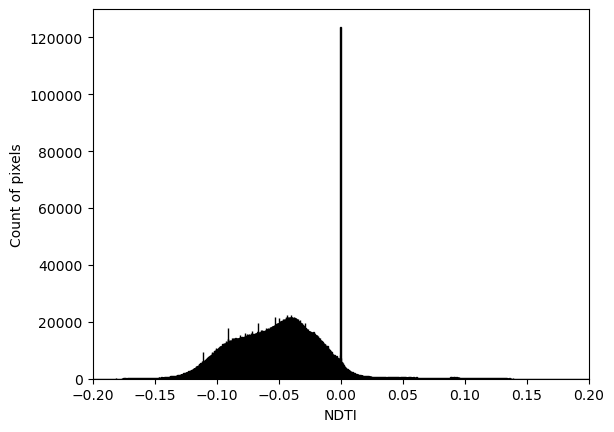

In [59]:
masked_ds["ndti"] = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

plt.hist(masked_ds.ndti.to_numpy().flatten(), color = 'blue', edgecolor = 'black',
         bins = 8000)
plt.xlim((-0.2,0.2))

# Add labels
plt.xlabel('NDTI')
plt.ylabel('Count of pixels')

(array([2.0000000e+00, 3.0000000e+00, 1.9000000e+01, 1.7467000e+04,
        2.1362350e+06, 1.5856648e+07, 2.4062630e+06, 1.9990000e+05,
        3.7700000e+02, 3.7000000e+01]),
 array([-0.52333093, -0.43855935, -0.35378778, -0.26901621, -0.18424463,
        -0.09947306, -0.01470149,  0.07007009,  0.15484166,  0.23961323,
         0.32438481]),
 <BarContainer object of 10 artists>)

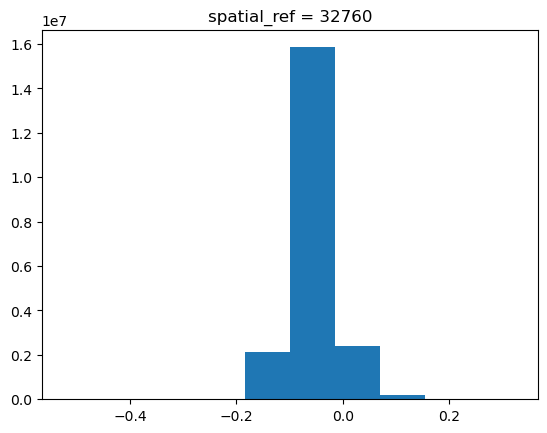

In [16]:
ndti.plot()

In [60]:
ndti.isel(time=0).odc.explore(cmap='BrBG_r', vmin=-0.2, vmax=0.2)


In [18]:
median = scaled.median("time").compute()
median_image = median.assign_coords(band=["coastal", "red", "green", "blue", "nir", "swir1", "swir2"])

<font color='red'>The formula for the Normalized Difference Turbidity Index (NDTI) is: 

<font color='red'>\(NDTI=(Red-Green)/(Red+Green)\)

<font color='red'>Define a variable to store NDTI using the median xarray dataset

In [19]:
ndti_median = (median_image["red"]-median_image["green"])/(median_image["red"]+median_image["green"])

AttributeError: Rectangle.set() got an unexpected keyword argument 'cmap'

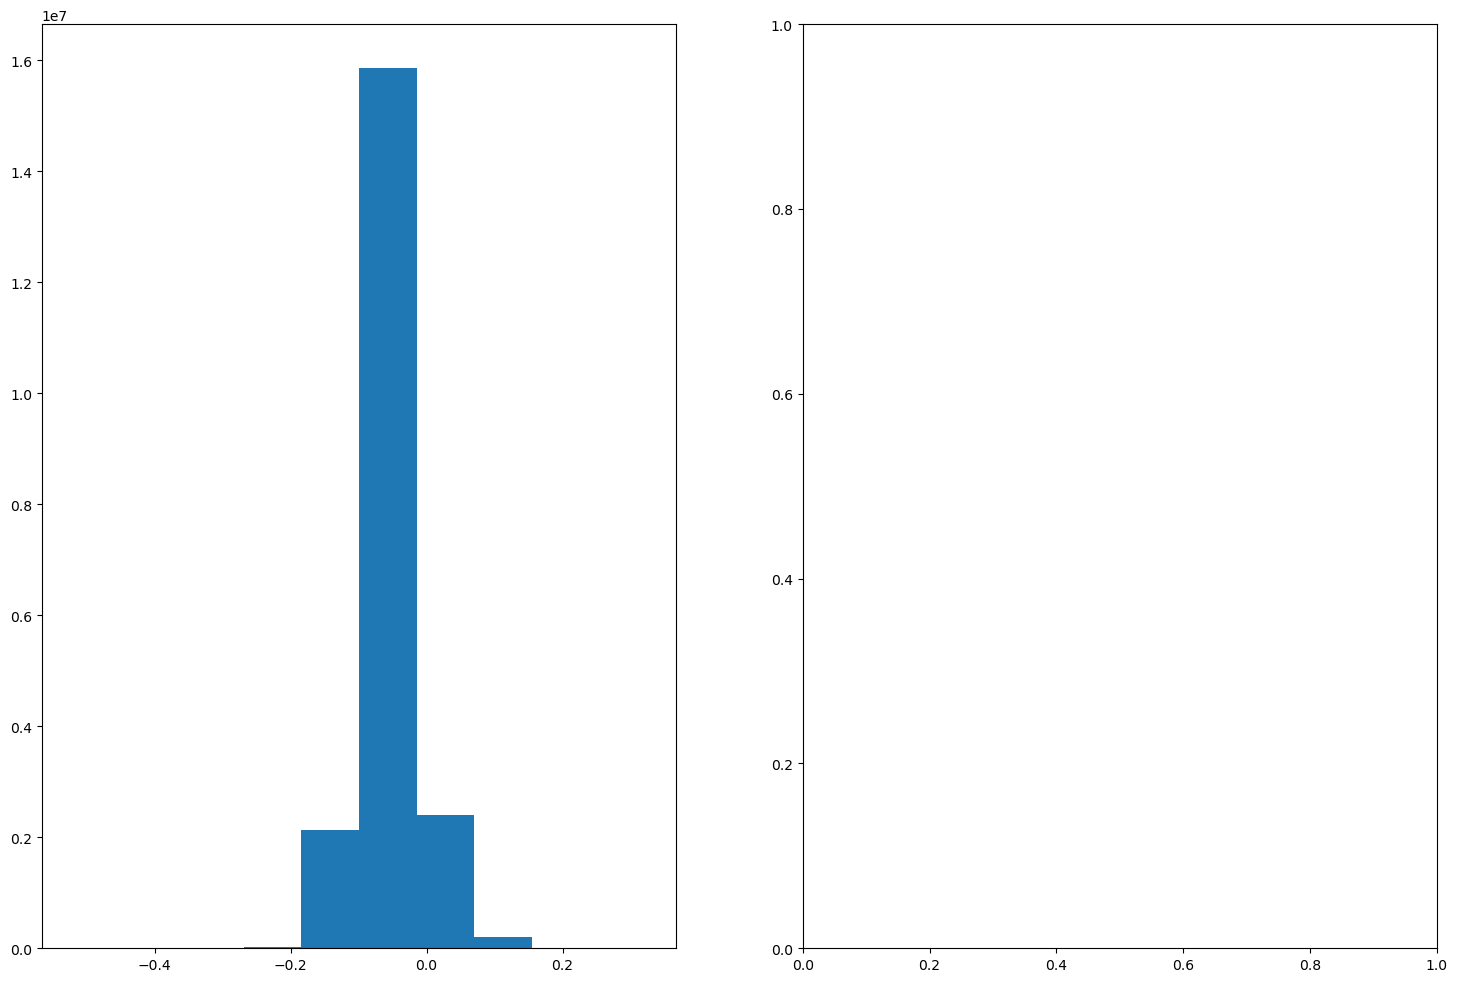

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(18, 12))
cmap='BrBG_r'
vmin=-1
vmax=1

ndti.plot(ax=ax[0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
ndti.plot(ax=ax[1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax);

In [ ]:
scaled.isel(time=5).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


In [ ]:
turbid = scaled.isel(time=5)
turbid = turbid.assign_coords(band=["coastal", "red", "green", "blue", "nir", "swir1", "swir2"])

In [ ]:
ndti_turbid = (turbid["red"]-turbid["green"])/(turbid["red"]+turbid["green"])

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 12))
cmap='BrBG_r'
vmin=-1
vmax=1

ndti_turbid.plot(ax=ax[0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
ndti_turbid.plot(ax=ax[1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax);

In [ ]:
ndti_turbid.odc.explore(cmap='BrBG_r', vmin=-1, vmax=1)
